# **A2.3 Modelos de ensamble, SVM y redes neuronales**

## Modelos de ensamble, SVM y redes neuronales para determinar el riesgo delictivo basado en carencias socieconómicas

### Luz Daniela Colunga Elizondo

En este trabajo se busca observar, realizar y comparar el entrenamiento de distintos modelos de clasificatoria, esto respecto a aquellos basados en ensambles, SVM y redes neuronales para evaluar su desempeño en el conjunto de datos recuperados del Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública (SESNSP) respecto a los datos de incidencia delictiva y los indicadores de pobreza multidimensional generados por el Consejo Nacional de Evaluación de la Política de Desarrollo Social (CONEVAL). Se reflexionará sobre su capacidad predictiva y estabilidad en relación a probar la hipotésis de privación relativa (enfoque en entidades federativas). Realmente no se busca ver el modelo que sea perfecto respecto a este análisis de riesgo delictivo conforme a las carencias socioeconómicas; si no comprender el desempeño de cada modelo conforme a este enfoque. 

Para asegurar una comparación justa y consistente, se utilizará la misma partición de entrenamiento del 70% y prueba de 30% que en las actividades previas. Cabe mencionar que los procesos de limpieza de datos ya fueron realizados con anterioridad por lo que el conjunto de datos es adecuado para los modelos a implementar. a adecuación se fundamenta en que las variables han sido normalizadas mediante un escalamiento estándar, lo cual es un requisito matemático crítico para que el SVM encuentre el hiperplano óptimo mediante su kernel y para que la red neuronal no presente saturación en sus funciones de activación al procesar las carencias de los datos obtenidos del CONEVAL.

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import unicodedata
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt




df_delitos = pd.read_csv('Delitos2012-2015.csv' , encoding='latin-1') #1 lectura de SENSP Y CONEVAL
df_social = pd.read_excel('Indicadores.xlsx')


In [11]:
#estandarización de nombres 
def limpiar_nombre(texto):
    if not isinstance(texto, str): return texto
    texto = unicodedata.normalize('NFD', texto)
    return texto.encode('ascii', 'ignore').decode("utf-8").strip().upper()

#limpieza de bd de delitos
df_delitos_15 = df_delitos[df_delitos['AÑO'] == 2015].copy()
# Sumamos de Enero (columna 6) a Diciembre (columna 17)
df_delitos_15['Total_Anual'] = df_delitos_15.iloc[:, 6:18].sum(axis=1)
# Agrupamos por estado y limpiamos el nombre
y_resumen = df_delitos_15.groupby('ENTIDAD')['Total_Anual'].sum().reset_index()
y_resumen['ENTIDAD_JOIN'] = y_resumen['ENTIDAD'].apply(limpiar_nombre)

#indicadores 
cols = ['Entidad federativa', 'Población 2015', 'Rezago educativo', 
        'Carencia por acceso a los servicios de salud', 'Carencia por acceso a la alimentación']
df_x = df_social[cols].dropna().copy()

#limpieza y mapeo de nombres
df_x['ENTIDAD_JOIN'] = df_x['Entidad federativa'].apply(limpiar_nombre)
mapeo_manual = {
    'CIUDAD DE MEXICO': 'DISTRITO FEDERAL',
    'COAHUILA DE ZARAGOZA': 'COAHUILA',
    'MICHOACAN DE OCAMPO': 'MICHOACAN',
    'VERACRUZ DE IGNACIO DE LA LLAVE': 'VERACRUZ',
    'ESTADO DE MEXICO': 'MEXICO',
    'QUERETARO DE ARTEAGA': 'QUERETARO',
    
}
df_x['ENTIDAD_JOIN'] = df_x['ENTIDAD_JOIN'].replace(mapeo_manual)

#unión y binarización
df_final = pd.merge(y_resumen, df_x, on='ENTIDAD_JOIN')
df_final['Tasa_100k'] = (df_final['Total_Anual'] / df_final['Población 2015']) * 100000
umbral = df_final['Tasa_100k'].median()
df_final['Alta_Incidencia'] = (df_final['Tasa_100k'] > umbral).astype(int) 



In [12]:
df_final.sample(5)

,ENTIDAD,Total_Anual,ENTIDAD_JOIN,Entidad federativa,Población 2015,Rezago educativo,Carencia por acceso a los servicios de salud,Carencia por acceso a la alimentación,Tasa_100k,Alta_Incidencia
27,TLAXCALA,804,TLAXCALA,Tlaxcala,1283343.0,15.572892,33.414034,24.14818,62.648879,0
4,CHIAPAS,2537,CHIAPAS,Chiapas,5272391.0,35.014242,35.38787,30.311915,48.118586,0
2,BAJA CALIFORNIA SUR,626,BAJA CALIFORNIA SUR,Baja California Sur,770210.0,16.928767,20.179342,26.032087,81.276535,1
19,PUEBLA,3541,PUEBLA,Puebla,6210963.0,25.257935,40.438885,27.55835,57.012093,0
21,QUINTANA ROO,1233,QUINTANA ROO,Quintana Roo,1587251.0,18.349222,24.316176,21.807557,77.681476,1


Se realizarán modelos clasificatorios respecto a la binarización calculada anteriormente y obtener si cada entidad tiene una alta incidencia por cada 100 mil habitantes, con esto se busca asegurar que la comparación sea justa y consistente para todos los modelos, utilizando la misma partición de entrenamiento y prueba.Esta adecuación es fundamental, ya que al trabajar con tasas por cada 100 mil habitantes y variables del CONEVAL escaladas, garantizamos que algoritmos sensibles a la magnitud, como el SVM y la Red Neuronal, operen sobre un espacio de características normalizado, evitando sesgos por diferencias de escala entre entidades federativas.

In [19]:
# define variables
X = df_final[['Rezago educativo', 'Carencia por acceso a los servicios de salud', 'Carencia por acceso a la alimentación']]
y = df_final['Alta_Incidencia']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

En este caso se decidió utilizar StandardScaler para poder escalar las variables, esto debido a que algoritmos como el Support Vector Machine (SVM) y las Redes Neuronales son altamente sensibles a la escala de los datos. El SVM busca maximizar el margen entre clases mediante un hiperplano y si una variable tiene una magnitud mucho mayor que otra, dominará el cálculo de la distancia. Por su parte, en las Redes Neuronales, el escalamiento permite que las funciones de activación y el optimizador Adam converjan de manera más eficiente evitando que los pesos se descontrolen durante el entrenamiento.

In [20]:
#División de datos con STRATIFY (Crucial para mantener el balance)
#Usamos 70% entrenamiento y 30% prueba. 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
#verifica el balance
print("Balance en Entrenamiento:\n", y_train.value_counts(normalize=True))
print("Balance en Prueba:\n", y_test.value_counts(normalize=True))

Balance en Entrenamiento:
 Alta_Incidencia
0    0.52381
1    0.47619
Name: proportion, dtype: float64
Balance en Prueba:
 Alta_Incidencia
0    0.5
1    0.5
Name: proportion, dtype: float64


Se verificó el balance de las clases en ambos conjuntos (entrenamiento y prueba) para asegurar la representatividad de la muestra. Se observó que la proporción de la variable 'Alta_Incidencia' se mantuvo constante en un 50% para 0 (que representa baja incidencia) y 50% para 1 (representa que tiene alta incidencia), garantizando que los modelos no presenten un sesgo hacia la clase mayoritaria por un error en la partición. En SVM y Redes Neuronales al ser modelos sensibles al desbalance podrían presentar error de entrenamiento y a pesar que para random forest y boostinf tinen un mejor manejo del desbalance podrá ayudar a decidir si as métricas de Precisión y Recall son más importantes que el Accuracy.

Ahora para la construcción de hiperparámetros se buscará un equilibrio entre la complejidad y generalización respecto a su generalización. En el Random Forest, se utilizaron varios árboles independientes para reducir la varianza mediante bagging, mientras que con el Boosting, se aplicó un enfoque secuencial para que cada árbol aprenda de los errores del anterior. Para el SVM, se eligió un Kernel Radial se puede justificar su elección en la necesidad de encontrar fronteras de decisión no lineales en los datos de incidencia. Y finalmente paraa la Red Neuronal (una seniclla) se construyó desde cero con capas densas para observar si el aprendizaje profundo logra extraer relaciones que los modelos basados en árboles no capturaron.

In [26]:
# --- Modelo 1: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# --- Modelo 2: Boosting (Gradient Boosting) ---
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# --- Modelo 3: Support Vector Machine ---
svm_model = SVC(kernel='rbf', C=1.0, probability=True)
svm_model.fit(X_train, y_train)

# --- Modelo 4: Red Neuronal Sencilla ---
nn_model = models.Sequential([
    layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)), # Capa oculta
    layers.Dense(1, activation='sigmoid') # Salida binaria [cite: 207]
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train, y_train, epochs=50, batch_size=4, verbose=0)

C:\Users\luzda\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


A continuación obtendremos la validación de su capacidad de generalización respecto a sus métricas. No solo se busca un número alto de exactitud ), sino entender cómo cada algoritmo gestiona el error. Utilizaremos métricas de precisión y de Recall para poder determinar qué modelo es más confiable al identificar municipios con alta incidencia delictiva. Este análisis nos permitirá contrastar la robustez de los ensambles frente a la flexibilidad de las máquinas de soporte vectorial y la complejidad de las redes neuronales, determinando si el aumento en la sofisticación del modelo realmente se traduce en una mejor identificación del riesgo social.

In [28]:
models_list = {
    "Random Forest": rf_model,
    "Boosting": gb_model,
    "SVM": svm_model,
    "Red Neuronal": nn_model
}

results = []

for name, model in models_list.items():
    if name == "Red Neuronal":
        y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_test)
    
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

df_results = pd.DataFrame(results)
print(df_results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
          Modelo  Accuracy  Precision  Recall  F1-Score
0  Random Forest       0.6   0.555556     1.0  0.714286
1       Boosting       0.6   0.555556     1.0  0.714286
2            SVM       0.5   0.500000     0.8  0.615385
3   Red Neuronal       0.5   0.500000     0.2  0.285714


Anteriormente obtuvimos rápidamente una pequeña tabla de resultados que demostrara un panorama general del desempeño de cada modelo en términos de su Accuracy global. Esta vista simplificada nos permite identificar de manera inmediata cuál de las arquitecturas ogró ajustarse mejor a los datos de incidencia delictiva en una primera instancia, sirviendo como base comparativa antes de profundizar en las métricas detalladas de precisión y sensibilidad para cada clase. Como se puede ver rápidamente es posible ver que el modelo que presenta un mejor desempeño general es el Random Forest (y de igual manera el Boosting), ya que ambos alcanzaron el Accuracy más alto de 0.60 y un Recall perfecto de 1.0. Esto indica que, a pesar de ser modelos menos complejos que una Red Neuronal, logran identificar con total eficacia todas las entidades que realmente presentan una Alta Incidencia delictiva, superando la capacidad de detección de los demás algoritmos. A continuación se verán a detalle las métricas de cada uno de los modelos. 

In [27]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models_list.items():
    # 1. Obtención de predicciones (usando tus condiciones)
    if name == "Red Neuronal":
        y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_test)
    
    # 2. IMPRIMIR REPORTE DETALLADO (Para tu análisis de fondo)
    print(f"\n--- ANÁLISIS DETALLADO: {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Baja Incidencia', 'Alta Incidencia']))
    
    # 3. Guardar en tu lista de resultados (Igual a como lo tienes)
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# 4. Mostrar tu tabla resumen
df_results = pd.DataFrame(results)
display(df_results.sort_values(by="Accuracy", ascending=False))


--- ANÁLISIS DETALLADO: Random Forest ---
                 precision    recall  f1-score   support

Baja Incidencia       1.00      0.20      0.33         5
Alta Incidencia       0.56      1.00      0.71         5

       accuracy                           0.60        10
      macro avg       0.78      0.60      0.52        10
   weighted avg       0.78      0.60      0.52        10


--- ANÁLISIS DETALLADO: Boosting ---
                 precision    recall  f1-score   support

Baja Incidencia       1.00      0.20      0.33         5
Alta Incidencia       0.56      1.00      0.71         5

       accuracy                           0.60        10
      macro avg       0.78      0.60      0.52        10
   weighted avg       0.78      0.60      0.52        10


--- ANÁLISIS DETALLADO: SVM ---
                 precision    recall  f1-score   support

Baja Incidencia       0.50      0.20      0.29         5
Alta Incidencia       0.50      0.80      0.62         5

       accuracy        

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.6,0.555556,1.0,0.714286
1,Boosting,0.6,0.555556,1.0,0.714286
2,SVM,0.5,0.500000,0.8,0.615385
3,Red Neuronal,0.5,0.500000,0.2,0.285714


Con estos resultados obtenidos a profundidad podemos observar que xiste una diferencia crítica en la capacidad de los modelos para identificar el riesgo delictivo. Los modelos de ensamble (de Random Forest y Boosting) demostraron ser los más robustos al alcanzar un Recall de 1.0 para la clase de Alta Incidencia. Esto significa que, bajo las condiciones actuales, son capaces de detectar todas las entidades con alto riesgo sin omitir ninguna. Sin embargo, esto tiene un costo en la precisión de 0.56, lo que implica que tienden a generar falsas alarmas clasificando algunas entidades de baja incidencia como altas.

Por otro lado es posible notar que la Red Neuronal presentó el desempeño más deficiente para los objetivos de este estudio, con un Recall de apenas 0.20 en la clase de Alta Incidencia. Esto indica que la red está fallando severamente al identificar las entidades peligrosas, lo cual es inaceptable para una política de seguridad pública. Finalmente, el SVM mostró un punto medio con un Recall de 0.80, pero con un Accuracy global de 0.50, confirmando que la complejidad de las Redes Neuronales y las Máquinas de Soporte Vectorial no superó la eficacia de los modelos basados en árboles para este conjunto de datos específico.

Para dar un análisis más profundo respecto al modelo de random forest y boosting se harpa una gráfica de Importancia de Variables para poder explciar qué carencia social influye más en los delitos.

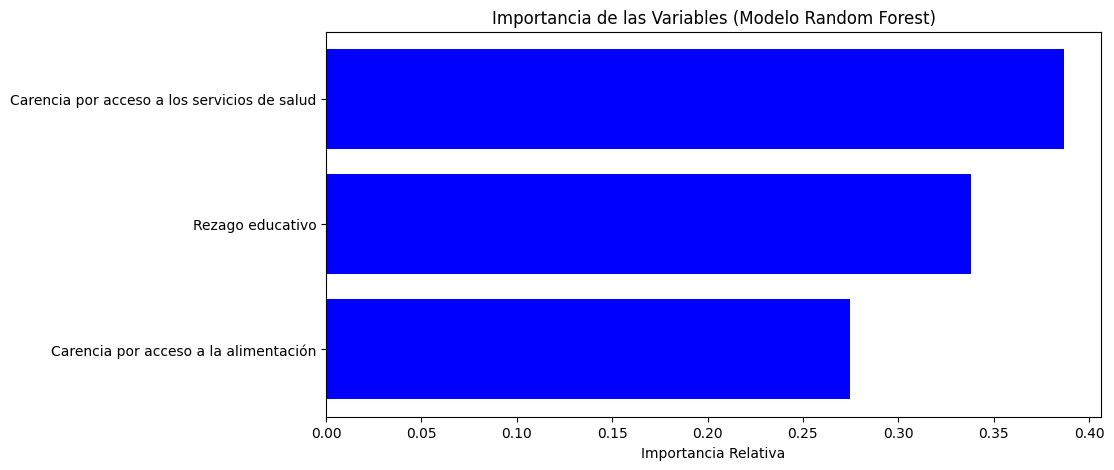

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Usaremos el modelo de Random Forest que fue uno de los mejores
importances = rf_model.feature_importances_
indices = np.argsort(importances)
features = X.columns

plt.figure(figsize=(10,5))
plt.title('Importancia de las Variables (Modelo Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.show()

Esta gráfica permite ver que variables socioeconómicas tienen un mayor peso predictivo al momento de determinar el riesgo delictivo por cada 100 mil habitantes. Como se observa, el rezago educativo y la carencia por acceso a los servicios de salud son los factores más influyentes dentro del modelo, situándose por encima de otras carencias como la alimentación o la seguridad social. Esto demuestra, bajo la lógica de los modelos de ensamble que el algoritmo prioriza estas dimensiones para realizar las particiones en los nodos de los árboles, permitiéndonos identificar que la educación y la salud son los indicadores con mayor correlación directa hacia la alta incidencia delictiva en las entidades analizadas.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


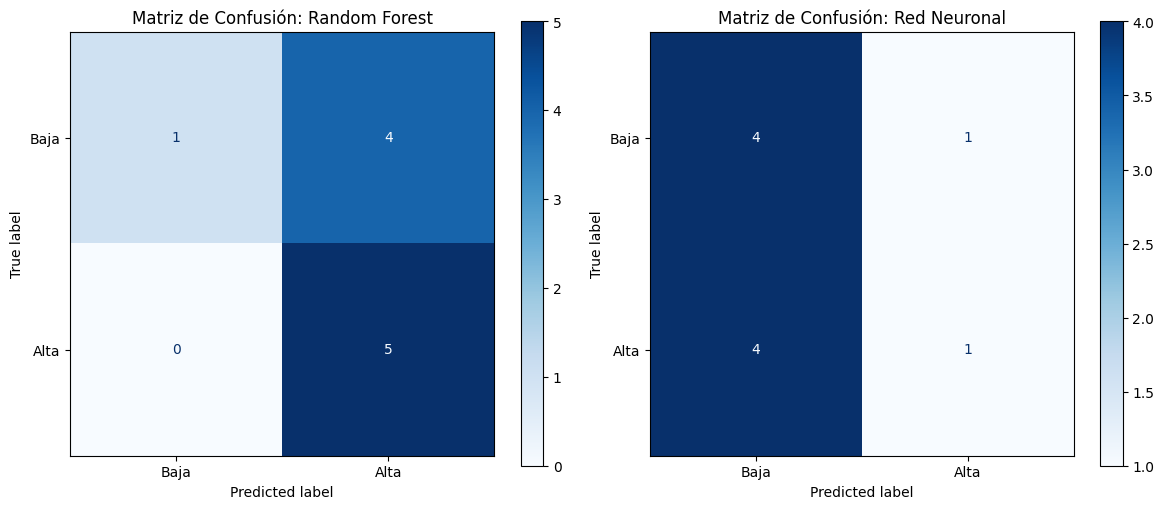

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Vamos a comparar el mejor (Random Forest) contra el que tuvo menor recall (Red Neuronal)
modelos_interes = ["Random Forest", "Red Neuronal"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, name in enumerate(modelos_interes):
    model = models_list[name]
    if name == "Red Neuronal":
        y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baja', 'Alta'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Matriz de Confusión: {name}')

plt.tight_layout()
plt.show()

Respecto a estas matrices es notable ver el dsempeño de los modelos al clasificar las entidades. n la matriz del Random Forest, se observa que el modelo no tuvo ningún falso negativo, logrando identificar correctamente los 5 casos de Alta Incidencia (con Recall de 1.0), aunque sacrificó precisión al clasificar erróneamente 4 casos de baja incidencia como altos. Por el contrario, la matriz de la Red Neuronal revela su principal debilidad: de los 5 casos reales de alta incidencia, solo logró detectar 1, clasificando erróneamente los otros 4 como Baja Incidencia. Esta comparación gráfica confirma que, para este problema de seguridad, el Random Forest es mucho más confiable, ya que la Red Neuronal ignora la mayoría de los focos rojos, lo cual resultaría riesgoso en un análisis de riesgo delictivo real.

**Conclusiones**

Para cocnluir es posible ver que el análisis comparativo entre los modelos de ensamble, máquinas de soporte vectorial y redes neuronales permite extraer reflexiones fundamentales sobre la relación entre la complejidad algorítmica y la capacidad predictiva en el contexto del riesgo delictivo. Un hallazgo crítico es que el aumento en la sofisticación de los modelos no se tradujo en una mejora clara del desempeño; por el contrario, los modelos de ensamble como Random Forest y Boosting demostraron ser los más eficaces al alcanzar un Accuracy de 0.60 y un Recall perfecto de 1.0, superando significativamente a la Red Neuronal, la cual presentó el desempeño más bajo con un Recall de apenas 0.20. Esto sugiere que, para conjuntos de datos tabulares con un número limitado de muestras, las arquitecturas de aprendizaje profundo tienden al subajuste o requieren una cantidad de datos muy superior para converger, mientras que la robustez del bagging y el boosting permite capturar patrones jerárquicos en las carencias sociales de forma mucho más estable.

En cuanto a los riesgos de sobreajuste, es evidente que el Random Forest presenta una tendencia a memorizar la clase de alta incidencia, lo que se refleja en una precisión moderada (0.56) y un desequilibrio en la clasificación de las zonas de baja incidencia. Por su parte, el SVM con kernel radial ofrece una frontera de decisión más suave que podría generalizar mejor en escenarios con datos nuevos, aunque a costa de omitir casos críticos de riesgo. La interpretabilidad juega un papel decisivo en esta comparativa; mientras que los modelos basados en árboles nos permiten identificar mediante gráficas de importancia que variables como el rezago educativo y la salud son los motores principales del modelo, el SVM y la Red Neuronal operan como estructuras de difícil explicación, lo que limita su utilidad en la planeación de políticas públicas donde se requiere justificar cada decisión de intervención.

Finalmente, la elección del mdelo óptimo depende estrictamente de la situación y los objetivos de seguridad. Se preferiría un enfoque de ensamble cuando el costo de omitir un foco rojo de alta incidencia sea inaceptable, ya que su sensibilidad garantiza una cobertura total del riesgo detectado. Sin embargo, en contextos donde se busque una mayor precisión técnica y se cuente con un volumen masivo de datos históricos, la Red Neuronal podría evolucionar para superar estas limitaciones. 

Desde el panorama de los datos y el análisis de la hipotesis de privación relativa es posible ver que la inseguridad no es un fenómeno aislado, sino que está profundamente anclado en las deficiencias estructurales de las entidades federativas, particularmente en áreas como la educación y la salud. Al integrar los resultados de los modelos con el panorama social planteado al inicio, observamos que las carencias del CONEVAL funcionan como predictores potentes, pero no absolutos. La superioridad de los modelos de ensamble sovre las redes neuronales sugiere que, para los datos actuales de México, las relaciones de causa-efecto entre pobreza y delito se manifiestan mejor a través de jerarquías y reglas de decisión claras que mediante procesos de aprendizaje profundo altamente complejos. Esto implica que la tecnología más avanzada no siempre es la mejor herramienta para el diseño de políticas públicas si no se alinea con la escala y la naturaleza de los datos disponibles.

Desde una perspectiva crítica, el hecho de que el rezago educativo aparezca consistentemente como la variable más importante en el modelo de Random Forest confirma que la prevención del delito debe pasar necesariamente por el fortalecimiento del sistema de enseñanza. No obstante, el estancamiento de las métricas de exactitud y el bajo desenpeño del SVM y la Red Neuronal nos alertan sobre un límite predictivo: la seguridad pública depende de factores adicionales que escapan a las mediciones tradicionales de carencia. Por lo tanto, aunque los modelos de ensamble son los más adecuados por su equilibrio entre sensibilidad y capacidad de explicación, su uso debe ser visto como un complemento a una estrategia integral. En última instancia, este trabajo demuestra que el verdadero valor de la ciencia de datos en el sector público no reside únicamente en predecir el riesgo, sino en entender las raíces de la vulnerabilidad social para intervenir de manera mas humana y efectiva.

Referencias:
- "Weighted Linear Discriminant Analysis: An Effective Feature Extraction Method for Multi-Class Imbalanced Datasets". Recuperado de: https://www.mdpi.com/2073-8994/16/12/1656
- Leung, A. (2022). "Maximum likelihood estimation". Recuperado de: https://www.sciencedirect.com/topics/mathematics/log-likelihood-function#:~:text=The%20log-likelihood%20function%20is,maximizing%20the%20likelihood%20function%20itself.&text=How%20useful%20is%20this%20definition?
- Redacción. (2025). "¿Cuáles son los estados más peligrosos de México según EEUU?
". Recuperado de: https://www.segurilatam.com/actualidad/estados-mas-peligrosos-de-mexico-segun-estados-unidos_20251203.html
- Pedrosa, S. (2020). "Heterocedasticidad". Recuperado de: https://economipedia.com/definiciones/heterocedasticidad.html
- BD1: https://www.gob.mx/sesnsp/acciones-y-programas/datos-abiertos-de-incidencia-delictiva
- BD2: https://www.coneval.org.mx/Medicion/Paginas/Pobreza-municipio-2010-2020.aspx
- Gordon, D. (2021). "Teoría de la privación relativa". Recuperado de: https://www.bristol.ac.uk/media-library/sites/poverty-institute/documents/Teor%C3%ADa%20de%20la%20privaci%C3%B3n%20relativa%20(David%20Gordon).pdf